# Redes Bayesianas Cuánticas

Una vez definidas las redes bayesianas clásicas, pasamos a ver cómo implementarlas mediante Computación Cuántica.

In [ ]:
import pennylane as qml
import numpy as np

## Probabilidades marginales

Para modelar las probabilidades marginales (i.e. las probabilidades de hechos independientes) aplicamos una rotación en función de dicha probabilidad:

$$P(A) \Rightarrow R_Y\left(2*acrsin\sqrt{P(A)}\right)\ket{0} = \ket{P(A)}$$

In [ ]:
def quantum_prob(prob, wire):
    qml.RY(2*np.arcsin(np.sqrt(prob)), wire)

In [ ]:
dev = qml.device("default.qubit", wires = 1)

@qml.qnode(dev)
def quantum_prob_example(prob):
    quantum_prob(prob, 0)
    return qml.state()

for x in np.linspace(0,1,11):
    print(f"{x:.1f}", quantum_prob_example(x))

## Probabilidades conjuntas

Para modelar las probabilidades conjuntas se utiliza un operador $MCX$ controlado por los qubits de las probabilidades marginales y actuando sobre el qubit que representará la probabilidad conjunta de ambas:

Si son independientes:

$$MCX(\ket{P(A)} \otimes \ket{P(B)} \otimes \ket{0}) = \ket{P(A)} \otimes \ket{P(B)} \otimes \ket{P(A,B)}$$

Si son dependientes:

$$MCX(\ket{P(A \mid B)} \otimes \ket{P(B)} \otimes \ket{0}) = \ket{P(A \mid B)} \otimes \ket{P(B)} \otimes \ket{P(A,B)}$$
$$MCX(\ket{P(B \mid A)} \otimes \ket{P(A)} \otimes \ket{0}) = \ket{P(B \mid A)} \otimes \ket{P(A)} \otimes \ket{P(A,B)}$$


#### Ejercicio 1

Implementa el operador cuántico para la probabilidad conjunta de dos evidencias.

In [ ]:
def quantum_prob_conj():
    ### YOUR CODE HERE
    pass

In [ ]:
dev # redefine according to your needs

@qml.qnode(dev)
def quantum_prob_conj_example():
    ### YOUR CODE HERE
    pass

# define a loop to test the operator with multiple inputs

## Probabilidades condicionales

Para modelar las probabilidades condicionales se utiliza un operador $CRY(\theta)$ donde $\theta$ por la probabilidad condicional; el operador actúa sobre un nuevo qubit y está controlado por la probabilidad que condiciona:

$$\theta = 2* arcsin\sqrt{P(A \mid B)}$$

$$CRY(\theta)\ket{P(B)} \otimes \ket{0} = \ket{P(B)} \otimes \ket{P(A)}$$

* Para aquellos casos donde la probabilidad condicional venga condicionada por más de un hecho (p.e.j: $P(A \mid B,C)$) será necesario utilizar múltiples controles, uno por cada probabilidad marginal.

### Ejercicio 2

Implementa el operador cuántico para la probabilidad condicional.

In [ ]:
def quantum_prob_cond(prob):
    ### YOUR CODE HERE
    pass

In [ ]:
dev # redefine according to your needs

@qml.qnode(dev)
def quantum_prob_cond_example(prob):
    ### YOUR CODE HERE
    pass

# define a loop to test the operator with multiple inputs

## Definición de redes

Con los elementos anteriores, definimos una red bayesiana cuántica de la siguiente forma:

1) Aplicamos el operador cuántico de probabilidad marginal a los qubits que representan hechos independientes de la red.
2) Aplicamos el operador cuántico de probabilidad condicional a los qubits que representan hechos dependientes de la red, controlados por los qubits independientes.

Con la red bayesiana cuántica definida, podemos obtener el estado de los qubits y realizar consultas como con la red clásica: se obtiene el estado, y se comprueban los qubits correspondientes.

Vamos a partir de una red bayesiana clásica y definir su equivalente cuántico. Para ello, utilizamos la librería ```pgmpy```, que proporciona funcionalidades para trabajar con redes bayesianas.

In [ ]:
%pip install pgmpy

Con esta librería vamos a crear una red bayesiana conocida como ```asia```, que trata sobre enfermedades pulmonares (tuberculosis, cáncer pulmonar y bronquitis) y su relación viajes a Asia.

In [ ]:
from IPython.display import Image
from pgmpy.example_models import load_model

# Load the model
asia_model = load_model('bnlearn/asia')

Así generamos la siguiente red:

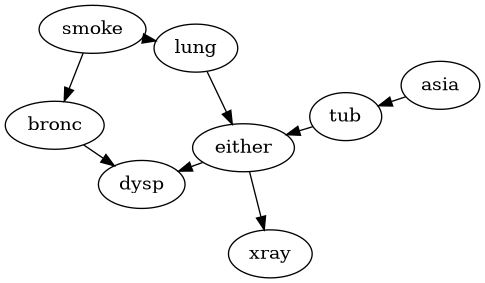

Esta red presenta las siguientes tablas de probabilidad condicional:

<table>
  <tr><th>asia</th><th>P(yes)</th><th>P(no)</th></tr>
  <tr><td>-</td><td>0.01</td><td>0.99</td></tr>
</table>
<br>
<table>
  <tr><th>smoke</th><th>P(yes)</th><th>P(no)</th></tr>
  <tr><td>-</td><td>0.5</td><td>0.5</td></tr>
</table>
<br>
<table>
  <tr><th>asia</th><th>P(tub=yes)</th><th>P(tub=no)</th></tr>
  <tr><td>yes</td><td>0.05</td><td>0.95</td></tr>
  <tr><td>no</td><td>0.01</td><td>0.99</td></tr>
</table>
<br>
<table>
  <tr><th>smoke</th><th>P(lung=yes)</th><th>P(lung=no)</th></tr>
  <tr><td>yes</td><td>0.1</td><td>0.9</td></tr>
  <tr><td>no</td><td>0.01</td><td>0.99</td></tr>
</table>
<br>
<table>
  <tr><th>smoke</th><th>P(bronc=yes)</th><th>P(bronc=no)</th></tr>
  <tr><td>yes</td><td>0.6</td><td>0.4</td></tr>
  <tr><td>no</td><td>0.3</td><td>0.7</td></tr>
</table>
<br>
<table>
  <tr>
    <th>lung</th><th>tub</th>
    <th>P(either=yes)</th><th>P(either=no)</th>
  </tr>
  <tr><td>yes</td><td>yes</td><td>1.0</td><td>0.0</td></tr>
  <tr><td>no</td><td>yes</td><td>1.0</td><td>0.0</td></tr>
  <tr><td>yes</td><td>no</td><td>1.0</td><td>0.0</td></tr>
  <tr><td>no</td><td>no</td><td>0.0</td><td>1.0</td></tr>
</table>
<br>
<table>
  <tr><th>either</th><th>P(xray=yes)</th><th>P(xray=no)</th></tr>
  <tr><td>yes</td><td>0.98</td><td>0.02</td></tr>
  <tr><td>no</td><td>0.05</td><td>0.95</td></tr>
</table>
<br>
<table>
  <tr>
    <th>bronc</th><th>either</th>
    <th>P(dysp=yes)</th><th>P(dysp=no)</th>
  </tr>
  <tr><td>yes</td><td>yes</td><td>0.9</td><td>0.1</td></tr>
  <tr><td>no</td><td>yes</td><td>0.7</td><td>0.3</td></tr>
  <tr><td>yes</td><td>no</td><td>0.8</td><td>0.2</td></tr>
  <tr><td>no</td><td>no</td><td>0.1</td><td>0.9</td></tr>
</table>

Con la red definida, se puede consultar la probabilidad de una determinada combinación de hechos:

In [ ]:
query = {"either": "no", "tub": "no", "xray": "yes", "bronc": "no"}

prob = asia_model.get_state_probability(
    {"either": "no", "tub": "no", "xray": "yes", "bronc": "no"}
)

print("P(either=F,tub=F,xray=T,bronc=F) = ", prob)

### Ejercicio 3

Implementa la red bayesiana ```asia``` mediante los operadores definidos previamente. Realiza 3 consultas como la anterior, tanto al modelo clásico como al cuántico, y compara los resultados.

In [ ]:
### YOUR CODE HERE